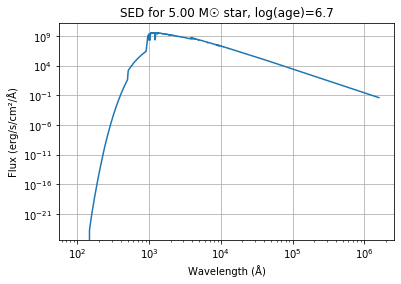

In [6]:
from spisea import synthetic, evolution, atmospheres, reddening
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# Parameters
mass = 5.0                      # Solar masses
log_age = 6.7                   # log(years)
metallicity = 0.0               # [Z]
AKs = 0.0                       # Extinction in Ks
distance = 10 * 1000           # parsecs

# Models
evo_model = evolution.MISTv1()
atm_func = atmospheres.get_merged_atmosphere
red_law = reddening.RedLawHosek18b()

# Generate isochrone
iso = synthetic.IsochronePhot(log_age, AKs, distance,
                                     evo_model=evo_model,
                                     atm_func=atm_func,
                                     red_law=red_law)

# Get the isochrone points table
points = iso.points

# Interpolate Teff and logg based on mass
mass_grid = points['mass']
teff_grid = points['Teff']
logg_grid = points['logg']

# Build interpolators
interp_teff = interp1d(mass_grid, teff_grid, bounds_error=False, fill_value='extrapolate')
interp_logg = interp1d(mass_grid, logg_grid, bounds_error=False, fill_value='extrapolate')

# Interpolate to desired mass
teff = float(interp_teff(mass))
logg = float(interp_logg(mass))

# Now get the SED
sed = atm_func(temperature=teff, gravity=logg, metallicity=metallicity)

# Plot the spectrum
wavelength = sed.wave  # Ångstroms
flux = sed.flux        # erg/s/cm^2/Å

plt.loglog(wavelength, flux)
plt.xlabel("Wavelength (Å)")
plt.ylabel("Flux (erg/s/cm²/Å)")
plt.title(f"SED for {mass:.2f} M☉ star, log(age)={log_age}")
plt.grid(True)
plt.show()